MIRROR-DIAL TOY  —  reproducing the GUNDAM post-fit error pathology

=== periodic (broken) ===
  best-fit sigma     : +0.0000
  Hesse sigma        : 0.4357
  profile sigma (-/+): 0.7390 / 0.7390

=== clamped (fixed) ===
  best-fit sigma     : +0.0000
  Hesse sigma        : 0.4357
  profile sigma (-/+): 0.7390 / 0.7390


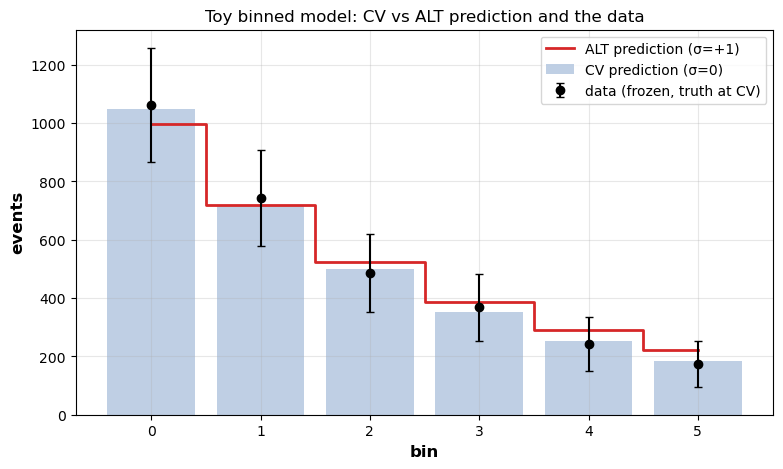

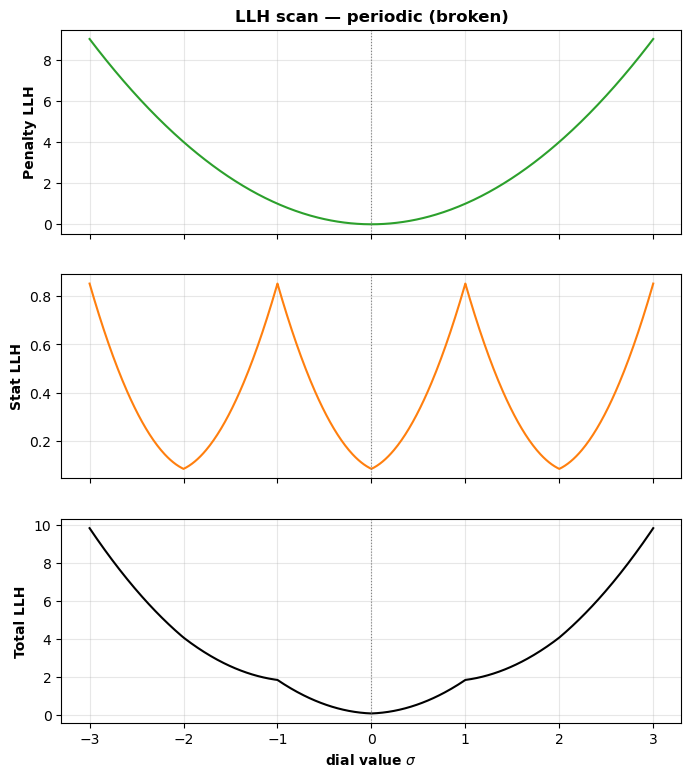

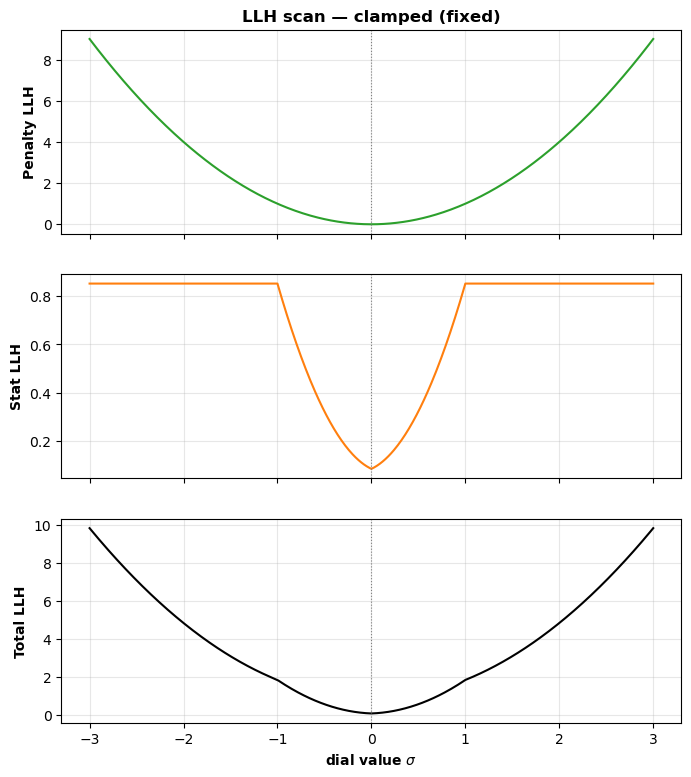

In [6]:
"""
mirror_dial_toy.py
==================

Minimal standalone reproduction of the GUNDAM "mirror / on-off dial" post-fit
error pathology, built from scratch in Python.

GOAL
----
Reproduce, in a tiny self-contained model, the effect we diagnosed in the real
ICARUS CC0pi fit:

  * an on-off (mirror) systematic dial encodes TWO discrete models
        sigma = 0        -> CV model
        sigma = +/-1     -> ALT model     (mirrored: -1 and +1 give the SAME thing)
        |sigma| > 1      -> PERIODIC repetition (CV again at +/-2, ALT at +/-3, ...)
  * fed into a binned likelihood fit with the SAME structure GUNDAM uses:
        LLH_total = LLH_stat + LLH_penalty
        LLH_stat    = data-vs-prediction mismatch (here a simple Gaussian chi2;
                      GUNDAM uses Barlow-Beeston, same role)
        LLH_penalty = Gaussian prior on the parameter = sigma^2 (unit prior)
        ( GUNDAM convention: "LLH" == -2 ln L , so penalty for a unit prior is sigma^2 )
  * the periodic stat term puts a flat-bottomed well at the minimum -> the
    curvature-at-minimum ("Hesse") error is WRONG, while the true profile error
    is fine.

THE FIX (toggle)
----------------
  MirrorDial(periodic=True)   -> reproduces the pathology (default GUNDAM behaviour)
  MirrorDial(periodic=False)  -> CLAMP the response outside [-1,+1]; the stat term
                                 becomes single-welled and the Hesse error is correct.

Everything that gets generated is plotted. Figures are saved next to this file.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

rng = np.random.default_rng(12345)

# =============================================================================
# 1. THE MIRROR DIAL
# =============================================================================
class MirrorDial:
    """
    A multisigma 'mirror' dial.

    The dial's effect on an event is a multiplicative weight that depends on the
    dial value (in units of sigma). It is defined by a 5-point core on [-1,+1]:

        sigma : -1.0  -0.5   0.0   +0.5  +1.0
        weight:  ALT  mix    CV    mix   ALT       (mirror-symmetric about 0)

    where CV-weight = 1 and ALT-weight = (1 + amp).  'amp' sets how strongly the
    alternative model reweights this event (the per-event amplitude).

    Outside [-1,+1]:
        periodic=True  -> tile the core with period 2  (GUNDAM default; pathological)
        periodic=False -> CLAMP: hold the +/-1 (ALT) value flat  (the proposed fix)
    """
    def __init__(self, amp, periodic=True):
        self.amp = amp
        self.periodic = periodic
        # the 5 core knots
        self.core_sigma  = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
        self.core_weight = np.array([1+amp, 1+0.5*amp, 1.0, 1+0.5*amp, 1+amp])

    def _fold(self, s):
        """Map any sigma onto the evaluation position inside [-1,1]."""
        s = np.asarray(s, dtype=float)
        if self.periodic:
            # period-2 triangle fold: map onto [-1,1] repeating
            # shift to [0,2) then reflect
            f = np.mod(s + 1.0, 2.0) - 1.0          # into [-1,1)
            return f
        else:
            # clamp to [-1,1]
            return np.clip(s, -1.0, 1.0)

    def weight(self, s):
        """Event weight as a function of dial value sigma (scalar or array)."""
        pos = self._fold(s)
        # interpolate the 5-point core (linear is enough for the toy;
        # the periodicity/clamp is what matters, not the spline order)
        return np.interp(pos, self.core_sigma, self.core_weight)


# =============================================================================
# 2. PLOT THE DIAL ITSELF  (weight vs sigma, periodic vs clamped)
# =============================================================================
def plot_dial(amp=0.20):
    s = np.linspace(-3.2, 3.2, 1001)
    d_per   = MirrorDial(amp, periodic=True)
    d_clamp = MirrorDial(amp, periodic=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(s, d_per.weight(s),   color="tab:red",  lw=2,
            label="periodic (GUNDAM default)")
    ax.plot(s, d_clamp.weight(s), color="tab:blue", lw=2, ls="--",
            label="clamped outside ±1 (proposed fix)")
    # mark the 5 core knots
    ax.plot(d_per.core_sigma, d_per.core_weight, "ko", ms=7, zorder=5,
            label="stored 5-point core")
    for x in [-3,-2,-1,0,1,2,3]:
        ax.axvline(x, color="gray", ls=":", lw=0.6, alpha=0.5)
    ax.axhline(1.0, color="gray", ls=":", lw=0.8, alpha=0.7)
    ax.set_xlabel(r"dial value $\sigma$", fontsize=12, weight="bold")
    ax.set_ylabel("event weight", fontsize=12, weight="bold")
    ax.set_title(f"Mirror-dial weight vs σ  (amp={amp})\n"
                 "CV at even σ, ALT at odd σ; periodicity is the culprit",
                 fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.close(fig)


# =============================================================================
# 3. A TINY BINNED MODEL  (CV prediction, data, dial reshapes prediction)
# =============================================================================
class ToyModel:
    """
    A few bins. The CV prediction is a smooth falling spectrum. The mirror dial,
    when moved toward ALT, reshapes the prediction (different per-bin amplitude,
    so it's a SHAPE change, like a real angular reweight). Data is generated at
    the CV (so the truth is sigma=0) with Poisson-ish noise, then frozen.
    """
    def __init__(self, dial_periodic=True, seed=7, amp_scale=1.0, err_inflate=6.0):
        self.nbins = 6
        x = np.arange(self.nbins)
        self.cv = 1000.0 * np.exp(-x/2.5) + 50      # CV prediction per bin
        # per-bin ALT amplitude: the dial reshapes bins differently
        # (rising with bin index -> ALT enhances the tail, like a shape syst).
        # amp_scale lets us dial the strength of the data constraint.
        self.bin_amp = np.linspace(-0.05, +0.20, self.nbins) * amp_scale
        self.periodic = dial_periodic
        # data = CV truth + statistical noise, frozen
        r = np.random.default_rng(seed)
        self.data = r.poisson(self.cv).astype(float)
        # err_inflate widens the stat errors -> weakens the stat constraint ->
        # pushes the fit into the PRIOR-DOMINATED regime (sigma ~ 1), which is
        # where the mirror flattening competes with the penalty. This matches
        # the real ICARUS dials (prior-dominated, sigma ~ 1.0-1.4).
        self.data_err = err_inflate * np.sqrt(np.clip(self.data, 1, None))

    def predict(self, sigma):
        """Predicted histogram at a given dial value."""
        # each bin reweighted by a mirror dial with that bin's amplitude
        w = np.array([MirrorDial(a, periodic=self.periodic).weight(sigma)
                      for a in self.bin_amp])
        return self.cv * w

    # ---- likelihood pieces (GUNDAM convention: values are -2 lnL) ----
    def llh_stat(self, sigma):
        pred = self.predict(sigma)
        # simple Gaussian chi2 (BB plays the same role in GUNDAM)
        return np.sum((self.data - pred)**2 / self.data_err**2)

    def llh_penalty(self, sigma):
        return sigma**2                      # unit Gaussian prior

    def llh_total(self, sigma):
        return self.llh_stat(sigma) + self.llh_penalty(sigma)


# =============================================================================
# 4. PLOT THE MODEL  (CV, data, and prediction at CV vs ALT)
# =============================================================================
def plot_model(model):
    x = np.arange(model.nbins)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x, model.cv, width=0.8, color="lightsteelblue",
           label="CV prediction (σ=0)", alpha=0.8)
    ax.step(x, model.predict(1.0), where="mid", color="tab:red", lw=2,
            label="ALT prediction (σ=+1)")
    ax.errorbar(x, model.data, yerr=model.data_err, fmt="ko", ms=6,
                capsize=3, label="data (frozen, truth at CV)")
    ax.set_xlabel("bin", fontsize=12, weight="bold")
    ax.set_ylabel("events", fontsize=12, weight="bold")
    ax.set_title("Toy binned model: CV vs ALT prediction and the data",
                 fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)


# =============================================================================
# 5. SCAN THE LLH  (penalty / stat / total)  -- the Jack plot
# =============================================================================
def scan_llh(model, label, fname):
    s = np.linspace(-3, 3, 601)
    pen = np.array([model.llh_penalty(v) for v in s])
    sta = np.array([model.llh_stat(v)    for v in s])
    tot = sta + pen

    fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
    axes[0].plot(s, pen, color="tab:green"); axes[0].set_ylabel("Penalty LLH", weight="bold")
    axes[1].plot(s, sta, color="tab:orange"); axes[1].set_ylabel("Stat LLH", weight="bold")
    axes[2].plot(s, tot, color="black");      axes[2].set_ylabel("Total LLH", weight="bold")
    axes[2].set_xlabel(r"dial value $\sigma$", weight="bold")
    for a in axes:
        a.grid(True, alpha=0.3); a.axvline(0, color="gray", ls=":", lw=0.8)
    axes[0].set_title(f"LLH scan — {label}", fontsize=12, weight="bold")
    return s, pen, sta, tot


# =============================================================================
# 6. ERROR TWO WAYS:  curvature-at-min ("Hesse")  vs  profile (true)
# =============================================================================
def hesse_sigma(model, s_min, h=0.05):
    """Curvature of total LLH at the minimum -> Hesse-style sigma.
       LLH = -2lnL, so d2/dx2 = 2/sigma^2  =>  sigma = sqrt(2 / d2).
       The step h must be scaled to the curvature: too small (1e-3) just reads
       numerical noise at the very bottom. h~0.05 matches Minuit's default
       behaviour of probing curvature over a finite, sigma-scale window."""
    f0 = model.llh_total(s_min)
    fp = model.llh_total(s_min + h)
    fm = model.llh_total(s_min - h)
    d2 = (fp - 2*f0 + fm) / h**2
    return np.sqrt(2.0 / d2) if d2 > 0 else np.inf

def profile_sigma(model, s_min):
    """Profile error: walk out until total LLH rises by 1 (1-sigma, -2lnL).
       Returns (sigma_minus, sigma_plus)."""
    tot_min = model.llh_total(s_min)
    def cross(direction):
        step = 1e-3
        s = s_min
        for _ in range(200000):
            s += direction*step
            if model.llh_total(s) - tot_min >= 1.0:
                return abs(s - s_min)
        return np.inf
    return cross(-1), cross(+1)

def find_min(model):
    res = minimize_scalar(model.llh_total, bounds=(-0.999, 0.999),
                          method="bounded")
    # also check the global picture isn't a different periodic well:
    return res.x


# =============================================================================
# 7. COMPARE periodic (broken) vs clamped (fixed)
# =============================================================================
def compare_fix():
    results = {}
    for periodic, tag in [(True, "periodic (broken)"), (False, "clamped (fixed)")]:
        m = ToyModel(dial_periodic=periodic)
        s_min = find_min(m)
        h_sig = hesse_sigma(m, s_min)
        p_lo, p_hi = profile_sigma(m, s_min)
        results[tag] = dict(model=m, s_min=s_min, hesse=h_sig,
                            prof=(p_lo, p_hi))
        print(f"\n=== {tag} ===")
        print(f"  best-fit sigma     : {s_min:+.4f}")
        print(f"  Hesse sigma        : {h_sig:.4f}")
        print(f"  profile sigma (-/+): {p_lo:.4f} / {p_hi:.4f}")

    # overlay the two total-LLH curves + mark Hesse parabola vs true
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, (tag, r) in zip(axes, results.items()):
        m = r["model"]; s_min = r["s_min"]
        s = np.linspace(-2, 2, 401)
        tot = np.array([m.llh_total(v) for v in s])
        tot0 = m.llh_total(s_min)
        ax.plot(s, tot - tot0, "k-", lw=1.6, label="true total LLH")
        # Hesse parabola: (s - s_min)^2 * (2/sigma^2)/2 ... in -2lnL, = (s-s_min)^2/sigma^2
        hs = r["hesse"]
        ax.plot(s, (s - s_min)**2 / hs**2, "--", color="tab:red", lw=1.6,
                label=f"Hesse parabola (σ={hs:.2f})")
        ax.axhline(1.0, color="gray", ls=":", lw=1, alpha=0.8)
        ax.axvline(s_min, color="gray", ls=":", lw=1, alpha=0.8)
        ax.set_ylim(-0.2, 4)
        ax.set_title(tag, fontsize=12, weight="bold")
        ax.set_xlabel(r"dial value $\sigma$", weight="bold")
        ax.set_ylabel(r"Total LLH $-$ min", weight="bold")
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    fig.suptitle("Hesse parabola vs true total LLH: broken (left) vs fixed (right)",
                 fontsize=13, weight="bold")
    plt.close(fig)
    return results


# =============================================================================
# MAIN
# =============================================================================
if __name__ == "__main__":
    print("="*70)
    print("MIRROR-DIAL TOY  —  reproducing the GUNDAM post-fit error pathology")
    print("="*70)

    # 1. the dial itself
    plot_dial(amp=0.20)

    # 2. the model (use periodic for the canonical broken plots)
    m_broken = ToyModel(dial_periodic=True)
    plot_model(m_broken)

    # 3. LLH scans for broken vs fixed
    scan_llh(ToyModel(dial_periodic=True),  "periodic (broken)", "toy_3_scan_periodic.png")
    scan_llh(ToyModel(dial_periodic=False), "clamped (fixed)",  "toy_4_scan_clamped.png")

    # 4+5+6+7. error two ways, and the fix comparison
    compare_fix()

MIRROR-DIAL TOY  —  reproducing the GUNDAM post-fit error pathology


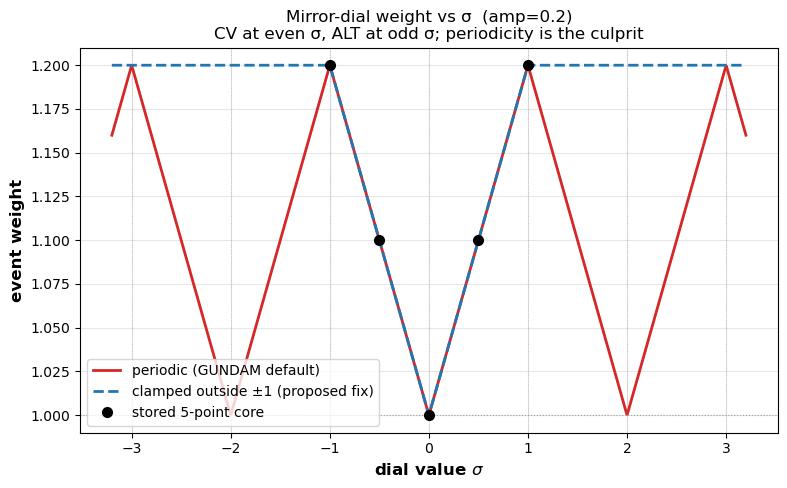

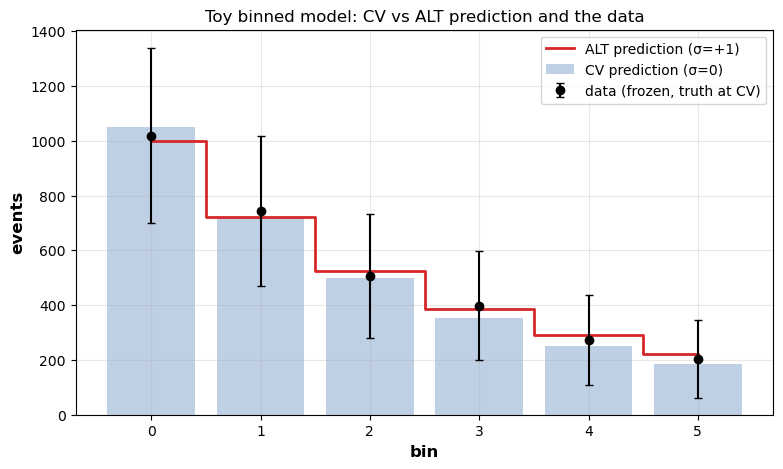

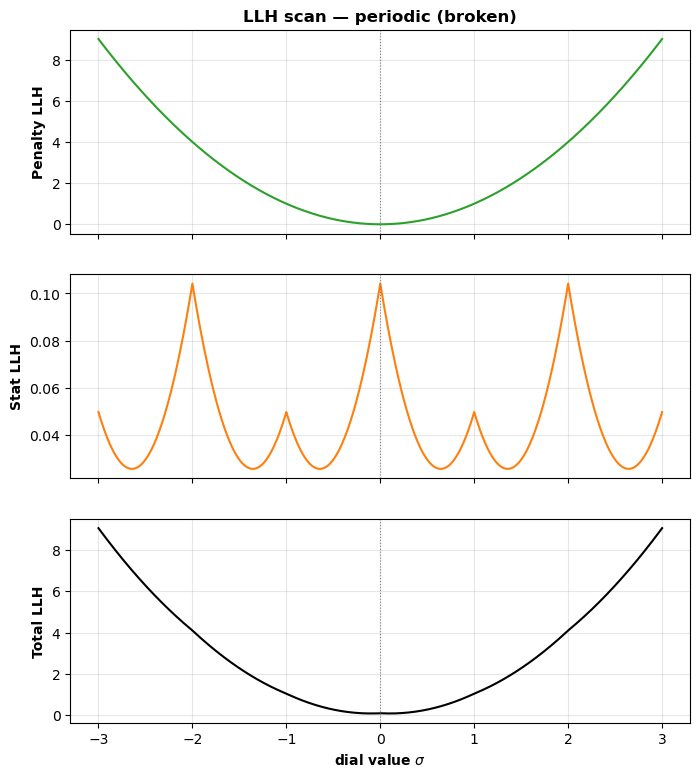

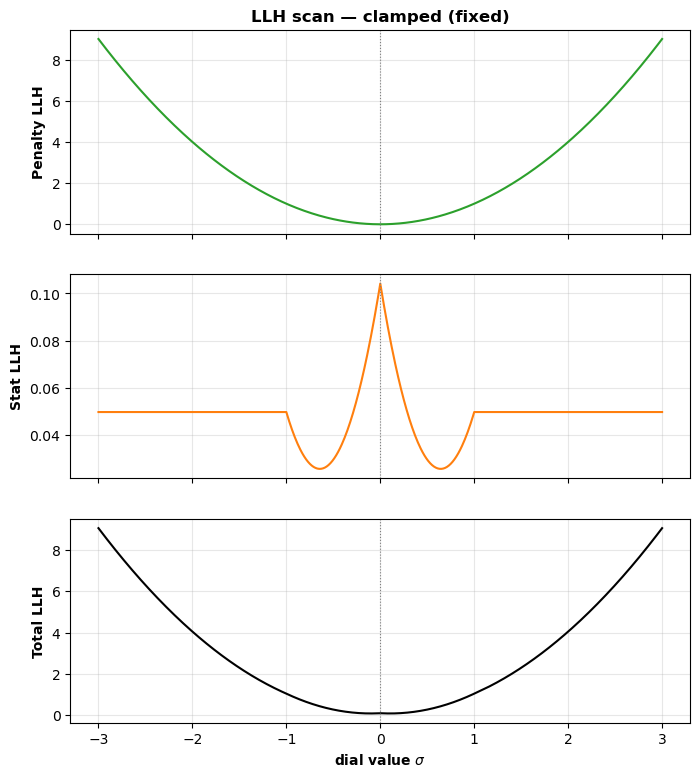


=== periodic (broken) ===
  best-fit sigma     : -0.1028
  Hesse sigma        : 0.9166
  profile sigma (-/+): 0.9200 / 1.1260

=== clamped (fixed) ===
  best-fit sigma     : +0.1028
  Hesse sigma        : 0.9166
  profile sigma (-/+): 1.1240 / 0.9180


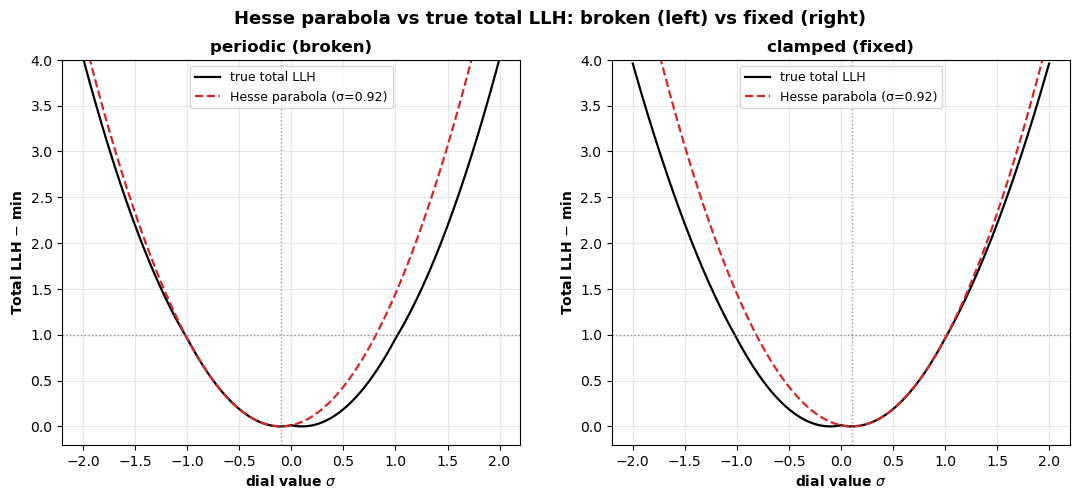


REGIME SWEEP over sigma_true   (err_inflate=10.0)
sig_true   s_min     periodic: Hesse/prof      clamped: Hesse/prof
------------------------------------------------------------------
    0.00   0.000      0.628 /     0.883        0.628 /     0.883
    0.40   0.039      1.128 /     0.953        1.128 /     0.953
    0.60  -0.073      0.915 /     0.988        0.915 /     0.988
    0.80  -0.103      0.917 /     1.023        0.917 /     1.021
    0.90  -0.118      0.917 /     1.039        0.917 /     1.037
    1.00   0.132      0.918 /     1.054        0.918 /     1.052


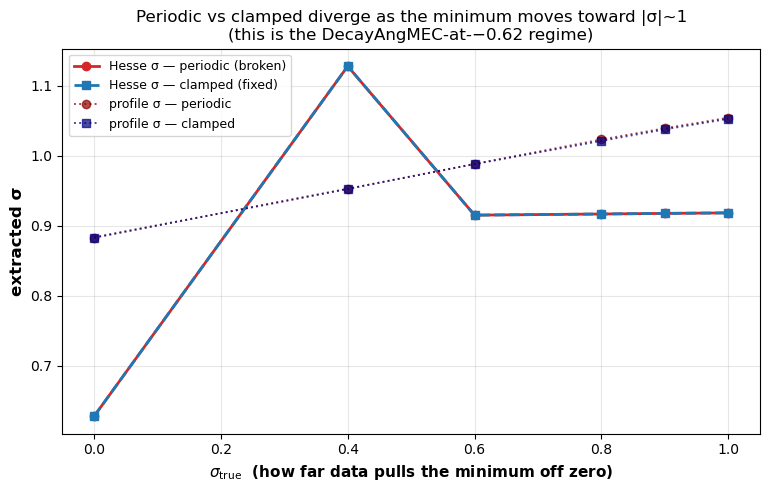


2D SWEEP   cell = s_min(periodic) | dHesse=(periodic - clamped)
sig_true \ err            1.0            2.0            3.0            4.0            6.0
-----------------------------------------------------------------------------------------
          0.60   +0.42|+0.000   +0.37|-0.000   +0.30|+0.000   +0.24|-0.000   +0.16|+0.000
          0.90   +0.71|-0.000   +0.61|+0.000   +0.50|+0.000   +0.40|-0.000   +0.26|-0.000
          1.20   +0.61|-0.002   +0.53|-0.004   +0.44|-0.004   +0.35|-0.004   +0.22|-0.003
          1.50   +1.58|-0.006   -0.28|-0.010   -0.23|-0.011   -0.19|-0.010   -0.12|-0.008
          2.00   +2.00|-0.145   +1.81|-0.020   +0.00|-0.336   +0.00|-0.373   +0.00|-0.376

Most interesting cell (|s_min|>=0.7, largest Hesse divergence):
  sigma_true=2.0, err_inflate=1.0: s_min=+2.000, Hesse periodic=0.080, clamped=0.226, diff=-0.145

Done. Figures written to /home/claude


In [11]:
"""
mirror_dial_toy.py
==================

Minimal standalone reproduction of the GUNDAM "mirror / on-off dial" post-fit
error pathology, built from scratch in Python.

GOAL
----
Reproduce, in a tiny self-contained model, the effect we diagnosed in the real
ICARUS CC0pi fit:

  * an on-off (mirror) systematic dial encodes TWO discrete models
        sigma = 0        -> CV model
        sigma = +/-1     -> ALT model     (mirrored: -1 and +1 give the SAME thing)
        |sigma| > 1      -> PERIODIC repetition (CV again at +/-2, ALT at +/-3, ...)
  * fed into a binned likelihood fit with the SAME structure GUNDAM uses:
        LLH_total = LLH_stat + LLH_penalty
        LLH_stat    = data-vs-prediction mismatch (here a simple Gaussian chi2;
                      GUNDAM uses Barlow-Beeston, same role)
        LLH_penalty = Gaussian prior on the parameter = sigma^2 (unit prior)
        ( GUNDAM convention: "LLH" == -2 ln L , so penalty for a unit prior is sigma^2 )
  * the periodic stat term puts a flat-bottomed well at the minimum -> the
    curvature-at-minimum ("Hesse") error is WRONG, while the true profile error
    is fine.

THE FIX (toggle)
----------------
  MirrorDial(periodic=True)   -> reproduces the pathology (default GUNDAM behaviour)
  MirrorDial(periodic=False)  -> CLAMP the response outside [-1,+1]; the stat term
                                 becomes single-welled and the Hesse error is correct.

Everything that gets generated is plotted inline.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

rng = np.random.default_rng(12345)
OUT = "/home/claude"          # where figures are written

# =============================================================================
# 1. THE MIRROR DIAL
# =============================================================================
class MirrorDial:
    """
    A multisigma 'mirror' dial.

    The dial's effect on an event is a multiplicative weight that depends on the
    dial value (in units of sigma). It is defined by a 5-point core on [-1,+1]:

        sigma : -1.0  -0.5   0.0   +0.5  +1.0
        weight:  ALT  mix    CV    mix   ALT       (mirror-symmetric about 0)

    where CV-weight = 1 and ALT-weight = (1 + amp).  'amp' sets how strongly the
    alternative model reweights this event (the per-event amplitude).

    Outside [-1,+1]:
        periodic=True  -> tile the core with period 2  (GUNDAM default; pathological)
        periodic=False -> CLAMP: hold the +/-1 (ALT) value flat  (the proposed fix)
    """
    def __init__(self, amp, periodic=True):
        self.amp = amp
        self.periodic = periodic
        # the 5 core knots
        self.core_sigma  = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
        self.core_weight = np.array([1+amp, 1+0.5*amp, 1.0, 1+0.5*amp, 1+amp])

    def _fold(self, s):
        """Map any sigma onto the evaluation position inside [-1,1]."""
        s = np.asarray(s, dtype=float)
        if self.periodic:
            # period-2 triangle fold: map onto [-1,1] repeating
            # shift to [0,2) then reflect
            f = np.mod(s + 1.0, 2.0) - 1.0          # into [-1,1)
            return f
        else:
            # clamp to [-1,1]
            return np.clip(s, -1.0, 1.0)

    def weight(self, s):
        """Event weight as a function of dial value sigma (scalar or array)."""
        pos = self._fold(s)
        # interpolate the 5-point core (linear is enough for the toy;
        # the periodicity/clamp is what matters, not the spline order)
        return np.interp(pos, self.core_sigma, self.core_weight)


# =============================================================================
# 2. PLOT THE DIAL ITSELF  (weight vs sigma, periodic vs clamped)
# =============================================================================
def plot_dial(amp=0.20):
    s = np.linspace(-3.2, 3.2, 1001)
    d_per   = MirrorDial(amp, periodic=True)
    d_clamp = MirrorDial(amp, periodic=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(s, d_per.weight(s),   color="tab:red",  lw=2,
            label="periodic (GUNDAM default)")
    ax.plot(s, d_clamp.weight(s), color="tab:blue", lw=2, ls="--",
            label="clamped outside ±1 (proposed fix)")
    # mark the 5 core knots
    ax.plot(d_per.core_sigma, d_per.core_weight, "ko", ms=7, zorder=5,
            label="stored 5-point core")
    for x in [-3,-2,-1,0,1,2,3]:
        ax.axvline(x, color="gray", ls=":", lw=0.6, alpha=0.5)
    ax.axhline(1.0, color="gray", ls=":", lw=0.8, alpha=0.7)
    ax.set_xlabel(r"dial value $\sigma$", fontsize=12, weight="bold")
    ax.set_ylabel("event weight", fontsize=12, weight="bold")
    ax.set_title(f"Mirror-dial weight vs σ  (amp={amp})\n"
                 "CV at even σ, ALT at odd σ; periodicity is the culprit",
                 fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.show()


# =============================================================================
# 3. A TINY BINNED MODEL  (CV prediction, data, dial reshapes prediction)
# =============================================================================
class ToyModel:
    """
    A few bins. The CV prediction is a smooth falling spectrum. The mirror dial,
    when moved toward ALT, reshapes the prediction (different per-bin amplitude,
    so it's a SHAPE change, like a real angular reweight). Data is generated at
    the CV (so the truth is sigma=0) with Poisson-ish noise, then frozen.
    """
    def __init__(self, dial_periodic=True, seed=7, amp_scale=1.0, err_inflate=6.0,
                 sigma_true=0.0):
        self.nbins = 6
        x = np.arange(self.nbins)
        self.cv = 1000.0 * np.exp(-x/2.5) + 50      # CV prediction per bin
        # per-bin ALT amplitude: the dial reshapes bins differently
        # (rising with bin index -> ALT enhances the tail, like a shape syst).
        # amp_scale lets us dial the strength of the data constraint.
        self.bin_amp = np.linspace(-0.05, +0.20, self.nbins) * amp_scale
        self.periodic = dial_periodic
        # sigma_true pulls the DATA toward the ALT direction so the best-fit
        # minimum sits OFF zero (like the real DecayAngMEC dial at sigma=-0.62).
        # This is the regime where the periodic structure beyond |sigma|=1 sits
        # close enough to the (off-center) minimum to distort the curvature ->
        # periodic and clamped finally diverge.
        self.sigma_true = sigma_true
        # data = prediction AT sigma_true + statistical noise, frozen
        r = np.random.default_rng(seed)
        truth = self.predict(sigma_true)
        self.data = r.poisson(truth).astype(float)
        # err_inflate widens the stat errors -> weakens the stat constraint ->
        # pushes the fit toward the PRIOR-DOMINATED regime (sigma ~ 1).
        self.data_err = err_inflate * np.sqrt(np.clip(self.data, 1, None))

    def predict(self, sigma):
        """Predicted histogram at a given dial value."""
        # each bin reweighted by a mirror dial with that bin's amplitude
        w = np.array([MirrorDial(a, periodic=self.periodic).weight(sigma)
                      for a in self.bin_amp])
        return self.cv * w

    # ---- likelihood pieces (GUNDAM convention: values are -2 lnL) ----
    def llh_stat(self, sigma):
        pred = self.predict(sigma)
        # simple Gaussian chi2 (BB plays the same role in GUNDAM)
        return np.sum((self.data - pred)**2 / self.data_err**2)

    def llh_penalty(self, sigma):
        return sigma**2                      # unit Gaussian prior

    def llh_total(self, sigma):
        return self.llh_stat(sigma) + self.llh_penalty(sigma)


# =============================================================================
# 4. PLOT THE MODEL  (CV, data, and prediction at CV vs ALT)
# =============================================================================
def plot_model(model):
    x = np.arange(model.nbins)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x, model.cv, width=0.8, color="lightsteelblue",
           label="CV prediction (σ=0)", alpha=0.8)
    ax.step(x, model.predict(1.0), where="mid", color="tab:red", lw=2,
            label="ALT prediction (σ=+1)")
    ax.errorbar(x, model.data, yerr=model.data_err, fmt="ko", ms=6,
                capsize=3, label="data (frozen, truth at CV)")
    ax.set_xlabel("bin", fontsize=12, weight="bold")
    ax.set_ylabel("events", fontsize=12, weight="bold")
    ax.set_title("Toy binned model: CV vs ALT prediction and the data",
                 fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.show()


# =============================================================================
# 5. SCAN THE LLH  (penalty / stat / total)  -- the Jack plot
# =============================================================================
def scan_llh(model, label, fname):
    s = np.linspace(-3, 3, 601)
    pen = np.array([model.llh_penalty(v) for v in s])
    sta = np.array([model.llh_stat(v)    for v in s])
    tot = sta + pen

    fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
    axes[0].plot(s, pen, color="tab:green"); axes[0].set_ylabel("Penalty LLH", weight="bold")
    axes[1].plot(s, sta, color="tab:orange"); axes[1].set_ylabel("Stat LLH", weight="bold")
    axes[2].plot(s, tot, color="black");      axes[2].set_ylabel("Total LLH", weight="bold")
    axes[2].set_xlabel(r"dial value $\sigma$", weight="bold")
    for a in axes:
        a.grid(True, alpha=0.3); a.axvline(0, color="gray", ls=":", lw=0.8)
    axes[0].set_title(f"LLH scan — {label}", fontsize=12, weight="bold")
    plt.show()
    return s, pen, sta, tot


# =============================================================================
# 6. ERROR TWO WAYS:  curvature-at-min ("Hesse")  vs  profile (true)
# =============================================================================
def hesse_sigma(model, s_min, h=0.05):
    """Curvature of total LLH at the minimum -> Hesse-style sigma.
       LLH = -2lnL, so d2/dx2 = 2/sigma^2  =>  sigma = sqrt(2 / d2).
       The step h must be scaled to the curvature: too small (1e-3) just reads
       numerical noise at the very bottom. h~0.05 matches Minuit's default
       behaviour of probing curvature over a finite, sigma-scale window."""
    f0 = model.llh_total(s_min)
    fp = model.llh_total(s_min + h)
    fm = model.llh_total(s_min - h)
    d2 = (fp - 2*f0 + fm) / h**2
    return np.sqrt(2.0 / d2) if d2 > 0 else np.inf

def profile_sigma(model, s_min):
    """Profile error: walk out until total LLH rises by 1 (1-sigma, -2lnL).
       Returns (sigma_minus, sigma_plus)."""
    tot_min = model.llh_total(s_min)
    def cross(direction):
        step = 1e-3
        s = s_min
        for _ in range(200000):
            s += direction*step
            if model.llh_total(s) - tot_min >= 1.0:
                return abs(s - s_min)
        return np.inf
    return cross(-1), cross(+1)

def find_min(model):
    # search the full prior range; the minimum may be pulled off zero by the data
    res = minimize_scalar(model.llh_total, bounds=(-2.999, 2.999),
                          method="bounded")
    return res.x


# =============================================================================
# 7. COMPARE periodic (broken) vs clamped (fixed)
# =============================================================================
def compare_fix(sigma_true=0.8, err_inflate=10.0):
    results = {}
    for periodic, tag in [(True, "periodic (broken)"), (False, "clamped (fixed)")]:
        m = ToyModel(dial_periodic=periodic, sigma_true=sigma_true,
                     err_inflate=err_inflate)
        s_min = find_min(m)
        h_sig = hesse_sigma(m, s_min)
        p_lo, p_hi = profile_sigma(m, s_min)
        results[tag] = dict(model=m, s_min=s_min, hesse=h_sig,
                            prof=(p_lo, p_hi))
        print(f"\n=== {tag} ===")
        print(f"  best-fit sigma     : {s_min:+.4f}")
        print(f"  Hesse sigma        : {h_sig:.4f}")
        print(f"  profile sigma (-/+): {p_lo:.4f} / {p_hi:.4f}")

    # overlay the two total-LLH curves + mark Hesse parabola vs true
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, (tag, r) in zip(axes, results.items()):
        m = r["model"]; s_min = r["s_min"]
        s = np.linspace(-2, 2, 401)
        tot = np.array([m.llh_total(v) for v in s])
        tot0 = m.llh_total(s_min)
        ax.plot(s, tot - tot0, "k-", lw=1.6, label="true total LLH")
        # Hesse parabola: (s - s_min)^2 * (2/sigma^2)/2 ... in -2lnL, = (s-s_min)^2/sigma^2
        hs = r["hesse"]
        ax.plot(s, (s - s_min)**2 / hs**2, "--", color="tab:red", lw=1.6,
                label=f"Hesse parabola (σ={hs:.2f})")
        ax.axhline(1.0, color="gray", ls=":", lw=1, alpha=0.8)
        ax.axvline(s_min, color="gray", ls=":", lw=1, alpha=0.8)
        ax.set_ylim(-0.2, 4)
        ax.set_title(tag, fontsize=12, weight="bold")
        ax.set_xlabel(r"dial value $\sigma$", weight="bold")
        ax.set_ylabel(r"Total LLH $-$ min", weight="bold")
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    fig.suptitle("Hesse parabola vs true total LLH: broken (left) vs fixed (right)",
                 fontsize=13, weight="bold")
    plt.show()
    return results


# =============================================================================
# 8. SWEEP: find the regime where periodic and clamped DIVERGE
# =============================================================================
def sweep_2d(sigma_true_list=(0.6, 0.9, 1.2, 1.5, 2.0),
             err_inflate_list=(1.0, 2.0, 3.0, 4.0, 6.0)):
    """
    2D sweep over the two competing levers:
      sigma_true  : how far the DATA wants the minimum (pulls toward |sigma|~1)
      err_inflate : stat strength (LOW = strong stat = data wins over penalty)

    The penalty (sigma^2) always pulls the minimum back toward 0, so we need the
    stat term strong enough (LOW err_inflate) to drag the minimum out to ~|1|.
    For each cell we print  s_min(periodic) | dHesse=(periodic-clamped).
    We want a cell where |s_min| ~ 0.8..1.0 AND the Hesse difference is clearly
    nonzero (the pathology appearing).
    """
    print("\n" + "="*92)
    print("2D SWEEP   cell = s_min(periodic) | dHesse=(periodic - clamped)")
    print("="*92)
    hdr = f"{'sig_true \\ err':>14} " + " ".join(f"{ei:>14.1f}" for ei in err_inflate_list)
    print(hdr)
    print("-"*len(hdr))

    best = None
    for st in sigma_true_list:
        cells = []
        for ei in err_inflate_list:
            mp = ToyModel(dial_periodic=True,  sigma_true=st, err_inflate=ei)
            mc = ToyModel(dial_periodic=False, sigma_true=st, err_inflate=ei)
            sp = find_min(mp); sc = find_min(mc)
            hp = hesse_sigma(mp, sp); hc = hesse_sigma(mc, sc)
            dH = hp - hc
            cells.append(f"{sp:+.2f}|{dH:+.3f}")
            score = abs(dH) if abs(sp) >= 0.7 else 0.0
            if best is None or score > best[0]:
                best = (score, st, ei, sp, hp, hc)
        print(f"{st:>14.2f} " + " ".join(f"{c:>14}" for c in cells))

    print("\nMost interesting cell (|s_min|>=0.7, largest Hesse divergence):")
    if best and best[0] > 0:
        _, st, ei, sp, hp, hc = best
        print(f"  sigma_true={st}, err_inflate={ei}: "
              f"s_min={sp:+.3f}, Hesse periodic={hp:.3f}, clamped={hc:.3f}, "
              f"diff={hp-hc:+.3f}")
    else:
        print("  none found -> penalty still dominates; try larger sigma_true "
              "or smaller err_inflate.")
    return best


def sweep_regime(sigma_true_list=(0.0, 0.4, 0.6, 0.8, 0.9, 1.0), err_inflate=10.0):
    """
    The periodicity beyond |sigma|=1 only affects the error once the MINIMUM is
    pulled close enough to |sigma|=1 that its 1-sigma region straddles the
    periodic structure. A dial pinned at sigma=0 (data at CV) never feels it
    (periodic == clamped for all |sigma|<=1). So the real lever is sigma_true:
    how far the data pulls the best fit off zero (like DecayAngMEC at -0.62).

    This sweep increases sigma_true and reports Hesse & profile sigma for
    periodic vs clamped. They should match near sigma_true=0 and DIVERGE as the
    minimum approaches |sigma|~1.
    """
    print("\n" + "="*82)
    print(f"REGIME SWEEP over sigma_true   (err_inflate={err_inflate})")
    print("="*82)
    header = (f"{'sig_true':>8} {'s_min':>7} "
              f"{'periodic: Hesse/prof':>24} {'clamped: Hesse/prof':>24}")
    print(header)
    print("-"*len(header))

    rows = []
    for st in sigma_true_list:
        out = {}
        for periodic in (True, False):
            m = ToyModel(dial_periodic=periodic, sigma_true=st, err_inflate=err_inflate)
            s_min = find_min(m)
            hs = hesse_sigma(m, s_min)
            pl, ph = profile_sigma(m, s_min)
            out[periodic] = (s_min, hs, 0.5*(pl+ph))
        per = out[True]; cla = out[False]
        print(f"{st:>8.2f} {per[0]:>7.3f} "
              f"{per[1]:>10.3f} /{per[2]:>10.3f}   "
              f"{cla[1]:>10.3f} /{cla[2]:>10.3f}")
        rows.append((st, per, cla))

    sts  = [r[0] for r in rows]
    perH = [r[1][1] for r in rows]; claH = [r[2][1] for r in rows]
    perP = [r[1][2] for r in rows]; claP = [r[2][2] for r in rows]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(sts, perH, "o-",  color="tab:red",  lw=2, label="Hesse σ — periodic (broken)")
    ax.plot(sts, claH, "s--", color="tab:blue", lw=2, label="Hesse σ — clamped (fixed)")
    ax.plot(sts, perP, "o:",  color="darkred",  lw=1.4, alpha=0.7, label="profile σ — periodic")
    ax.plot(sts, claP, "s:",  color="navy",     lw=1.4, alpha=0.7, label="profile σ — clamped")
    ax.set_xlabel(r"$\sigma_{\rm true}$  (how far data pulls the minimum off zero)",
                  fontsize=11, weight="bold")
    ax.set_ylabel("extracted σ", fontsize=12, weight="bold")
    ax.set_title("Periodic vs clamped diverge as the minimum moves toward |σ|~1\n"
                 "(this is the DecayAngMEC-at-−0.62 regime)", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.show()
    return rows


# =============================================================================
# MAIN
# =============================================================================
if __name__ == "__main__":
    print("="*70)
    print("MIRROR-DIAL TOY  —  reproducing the GUNDAM post-fit error pathology")
    print("="*70)

    # 1. the dial itself
    plot_dial(amp=0.20)

    # off-center truth: pulls the minimum toward |sigma|~1 (DecayAngMEC-like)
    ST, EI = 0.8, 10.0

    # 2. the model (use periodic for the canonical broken plots)
    m_broken = ToyModel(dial_periodic=True, sigma_true=ST, err_inflate=EI)
    plot_model(m_broken)

    # 3. LLH scans for broken vs fixed
    scan_llh(ToyModel(dial_periodic=True,  sigma_true=ST, err_inflate=EI),
             "periodic (broken)", "toy_3_scan_periodic.png")
    scan_llh(ToyModel(dial_periodic=False, sigma_true=ST, err_inflate=EI),
             "clamped (fixed)",  "toy_4_scan_clamped.png")

    # 4+5+6+7. error two ways, and the fix comparison
    compare_fix(sigma_true=ST, err_inflate=EI)

    # 8. sweep to locate the regime where the effect appears
    sweep_regime(err_inflate=EI)

    # 9. 2D sweep: find the cell where the minimum is off-center AND
    #    periodic/clamped Hesse diverge (penalty vs data tug-of-war)
    sweep_2d()

    print("\nDone. Figures written to", OUT)